In [2]:
from pyspark.sql import SparkSession
from minio import Minio

spark = SparkSession.builder \
    .appName("TipPrediction") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

# Spark uses Hadoop configs internally to connect to storage systems like S3 / MinIO
hadoop_conf = spark._jsc.hadoopConfiguration()
hadoop_conf.set("fs.s3a.endpoint", "http://minio:9000")
hadoop_conf.set("fs.s3a.access.key", "minioadmin")
hadoop_conf.set("fs.s3a.secret.key", "minioadmin123")
hadoop_conf.set("fs.s3a.path.style.access", "true")        # Required for MinIO because it uses path-style URLs instead of virtual-hosted style
                                                           # Example path-style: http://minio:9000/bucket-name/object
hadoop_conf.set("fs.s3a.connection.ssl.enabled", "false")  # MinIO is running on HTTP locally (not HTTPS)



In [3]:
# ---------- Connect to MinIO ----------

minio_client = Minio(
    "minio:9000",
    access_key="minioadmin",
    secret_key="minioadmin123",
    secure=False
)

bucket_name = "nyc-taxi"

# Print all objects present inside the bucket
# This helps verify whether parquet files exist and are accessible
print("\n" + "="*60)
print(f"Objects inside '{bucket_name}':")
for obj in minio_client.list_objects(bucket_name, recursive=True):
    print(f" - {obj.object_name} ({obj.size} bytes)")
print("="*60)
print("NYC Taxi Parquet Upload Complete")
print("="*60)


Objects inside 'nyc-taxi':
 - 2023/yellow_tripdata_2023-01.parquet (47673370 bytes)
 - 2023/yellow_tripdata_2023-02.parquet (47748012 bytes)
 - 2023/yellow_tripdata_2023-03.parquet (56127762 bytes)
 - 2023/yellow_tripdata_2023-04.parquet (54222699 bytes)
 - 2023/yellow_tripdata_2023-05.parquet (58654627 bytes)
 - 2023/yellow_tripdata_2023-06.parquet (54999465 bytes)
 - 2023/yellow_tripdata_2023-07.parquet (48361828 bytes)
 - 2023/yellow_tripdata_2023-08.parquet (48152353 bytes)
 - 2023/yellow_tripdata_2023-09.parquet (47895515 bytes)
 - 2023/yellow_tripdata_2023-10.parquet (59009059 bytes)
 - 2023/yellow_tripdata_2023-11.parquet (56094653 bytes)
 - 2023/yellow_tripdata_2023-12.parquet (56804275 bytes)
 - 2024/yellow_tripdata_2024-01.parquet (49961641 bytes)
 - 2024/yellow_tripdata_2024-02.parquet (50349284 bytes)
 - 2024/yellow_tripdata_2024-03.parquet (60078280 bytes)
 - 2024/yellow_tripdata_2024-04.parquet (59133625 bytes)
 - 2024/yellow_tripdata_2024-05.parquet (62553128 bytes)
 - 

In [4]:
from pyspark.sql.functions import col

# Month 1 (January) has a different schema than the other files. Therefore, some of its columns' data types have been changed.
# Also, the Airport_fee column name was different, so it has been changed as well.

# Read January separately and cast to match the standard schema
df_jan = spark.read.parquet("s3a://nyc-taxi/2023/yellow_tripdata_2023-01.parquet")

df_jan = df_jan \
    .withColumn("VendorID", col("VendorID").cast("integer")) \
    .withColumn("passenger_count", col("passenger_count").cast("long")) \
    .withColumn("RatecodeID", col("RatecodeID").cast("long")) \
    .withColumn("PULocationID", col("PULocationID").cast("integer")) \
    .withColumn("DOLocationID", col("DOLocationID").cast("integer")) \
    .withColumnRenamed("airport_fee", "Airport_fee")

# Read the rest (Feb-Dec)
df_rest = spark.read.parquet(
    "s3a://nyc-taxi/2023/yellow_tripdata_2023-0[2-9].parquet",
    "s3a://nyc-taxi/2023/yellow_tripdata_2023-1[0-2].parquet"
)

# Union them together
df1 = df_jan.union(df_rest)

In [5]:
# Combining parquet files from all the folders to create a single dataframe.

from pyspark.sql.functions import lit

df2 = spark.read.parquet("s3a://nyc-taxi/2024/*.parquet")
df_1_2 = df1.union(df2)

# Newer congestion charge (column name - cbd_congestion_fee) was introduced in 2025's datasets. 
# So, to union it with previous years' dataframes, we created the same column in previous years' dataframes.

df_1_2 = df_1_2.withColumn('cbd_congestion_fee', lit(0.0))
df3 = spark.read.parquet("s3a://nyc-taxi/2025/*.parquet")
df = df_1_2.union(df3)
df.count()

111036384

# EDA

In [5]:
df.describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+---------------------+------------------+--------------------+-------------------+-------------------+
|summary|          VendorID|   passenger_count|     trip_distance|        RatecodeID|store_and_fwd_flag|      PULocationID|      DOLocationID|     payment_type|       fare_amount|             extra|           mta_tax|        tip_amount|      tolls_amount|improvement_surcharge|      total_amount|congestion_surcharge|        Airport_fee| cbd_congestion_fee|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+---------------------+-------

We can see three problems with the data through the summary statistics - 
1. Many rows don't contain any value in the passenger count column.
2. The min values of fees and amount-related columns are negative.
3. The max values for the trip_distance and fare_amount columns are too high.
4. Zero trip_distance and fare_amount values.

### Going through the rows with null values in the passenger count column.

In [6]:
from pyspark.sql.functions import col

df_null_passenger = df.filter(col("passenger_count").isNull())
# df_null_passenger.describe().show()

In [7]:
df_null_passenger.groupBy("VendorID").count().show()

+--------+--------+
|VendorID|   count|
+--------+--------+
|       1| 2391564|
|       2|10333323|
|       6|   19291|
+--------+--------+



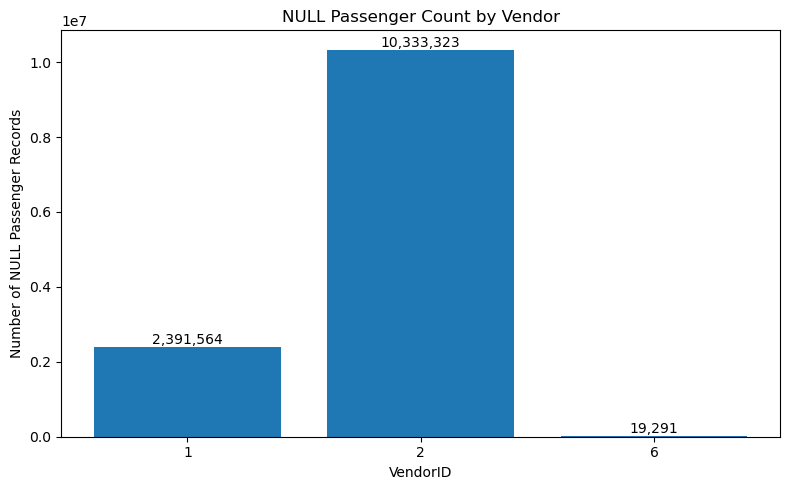

In [9]:
# pdf = df_null_passenger.groupBy("VendorID").count().toPandas()

# # Plot
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8, 5))
# plt.bar(pdf["VendorID"], pdf["count"])
# plt.xlabel("VendorID")
# plt.ylabel("Number of NULL Passenger Records")
# plt.title("NULL Passenger Count by Vendor")
# plt.xticks(pdf["VendorID"])
# plt.tight_layout()
# plt.show()

# Convert Spark DataFrame to Pandas
pdf = df_null_passenger.groupBy("VendorID").count().toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
bars = plt.bar(pdf["VendorID"].astype(str), pdf["count"])

plt.xlabel("VendorID")
plt.ylabel("Number of NULL Passenger Records")
plt.title("NULL Passenger Count by Vendor")

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",   # comma-formatted numbers
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


In [8]:
df_null_passenger.groupBy("PULocationID").count().show()

+------------+------+
|PULocationID| count|
+------------+------+
|         148|246081|
|         243| 30060|
|          31|   923|
|         137|180374|
|          85| 13129|
|          65| 43493|
|         255| 84605|
|          53|  2760|
|         133|  8166|
|          78|  6104|
|         155|  6324|
|         108|  2026|
|         211|137590|
|         193| 15606|
|          34|  6386|
|         101|  2033|
|         126|  5921|
|          81|  3948|
|          28|  9754|
|         210|  4470|
+------------+------+
only showing top 20 rows



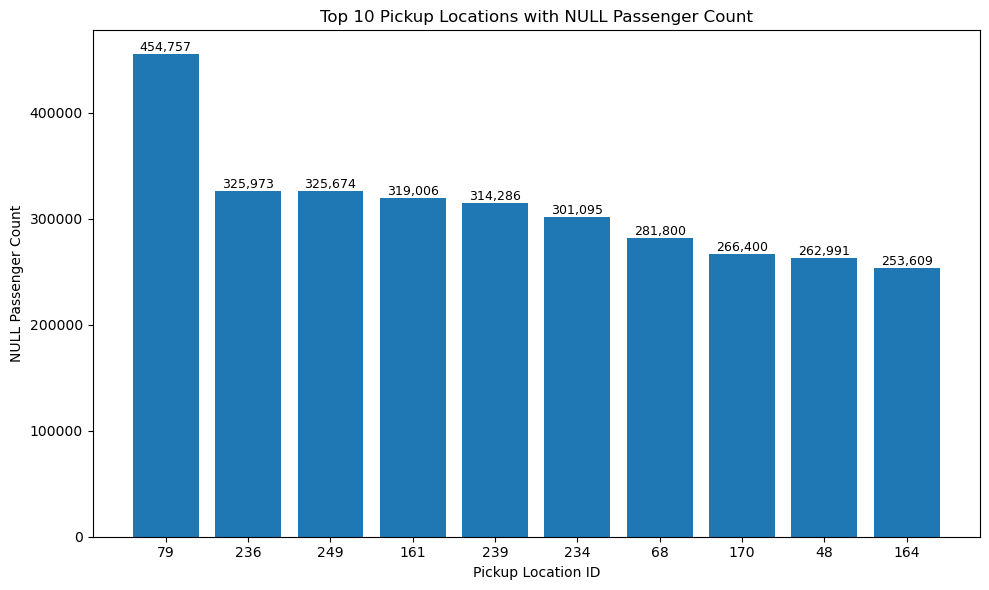

In [11]:
# Convert Spark DataFrame to Pandas
pdf = df_null_passenger.groupBy("PULocationID").count().toPandas()

# Take only top 10 locations (highest NULL counts) for better visualization clarity
pdf_top10 = pdf.sort_values("count", ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(
    pdf_top10["PULocationID"].astype(str),
    pdf_top10["count"]
)

plt.xlabel("Pickup Location ID")
plt.ylabel("NULL Passenger Count")
plt.title("Top 10 Pickup Locations with NULL Passenger Count")

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [12]:
df_null_passenger.groupBy("DOLocationID").count().show()

+------------+------+
|DOLocationID| count|
+------------+------+
|         148|236461|
|         243| 85820|
|          31|  1774|
|         137|179076|
|          85| 13306|
|          65| 22668|
|         255| 41330|
|          53|  6211|
|         133|  7503|
|          78|  7578|
|         155|  7884|
|         108|  3590|
|         211|125434|
|         193| 11754|
|          34|  4322|
|         126|  6356|
|         101|  2569|
|          81|  4304|
|          28|  9795|
|         210|  6891|
+------------+------+
only showing top 20 rows



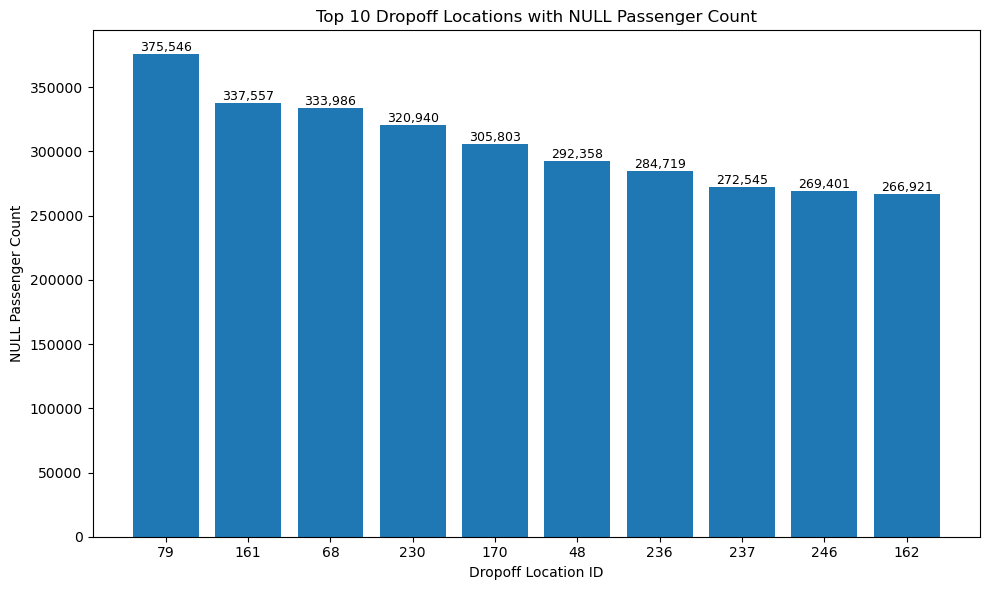

In [13]:
# Convert Spark DataFrame to Pandas
pdf = df_null_passenger.groupBy("DOLocationID").count().toPandas()

# Take only top 10 dropoff locations (highest NULL counts) for better visualization clarity
pdf_top10 = pdf.sort_values("count", ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(
    pdf_top10["DOLocationID"].astype(str),
    pdf_top10["count"]
)

plt.xlabel("Dropoff Location ID")
plt.ylabel("NULL Passenger Count")
plt.title("Top 10 Dropoff Locations with NULL Passenger Count")

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


This shows there is not a pattern with null values for a specific vendor or location. Therefore we can go ahead with removing these rows with null values.

In [7]:
df = df.dropna()
# df.count()

### For tipping prediction/analysis, negative amounts are not normal “real trips”, so we are going to exclude them

In [8]:
df = df.filter(
    (col("fare_amount") >= 0) &
    (col("trip_distance") >= 0) &
    (col("total_amount") >= 0) &
    (col("tip_amount") >= 0) &
    (col("extra") >= 0) &
    (col("mta_tax") >= 0) &
    (col("tolls_amount") >= 0) &
    (col("improvement_surcharge") >= 0) &
    (col("congestion_surcharge") >= 0) &
    (col("Airport_fee") >= 0) &
    (col("cbd_congestion_fee") >= 0)
)

# df.describe().show()

### Now, we will do the outlier analysis for trip distance

In [ ]:
df.select("trip_distance").describe().show()

In [9]:
q1, median, q3 = df.approxQuantile("trip_distance", [0.25, 0.5, 0.75], 0.01)

iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("Q1:", q1)
print("Median:", median)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/socket.py", line 706, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
ConnectionResetError: [Errno 104] Connection reset by peer

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 539, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending or receiving
ERRO

ConnectionRefusedError: [Errno 111] Connection refused

In [ ]:
from pyspark.sql.functions import col

outliers_df = df.filter((col("trip_distance") < lower) | (col("trip_distance") > upper))
normal_df   = df.filter((col("trip_distance") >= lower) & (col("trip_distance") <= upper))

print("Normal Rows:", normal_df.count())
print("Outlier Rows:", outliers_df.count())

The IQR method won't be applicable here since the outlier rows are in millions. So, we will take 100 as the outlier distance.

In [ ]:
long_distance_df = df.filter(col("trip_distance") > 100)

print("Long Distance Rows:", long_distance_df.count())

In [ ]:
total_rows = df.count()
long_distance_rows = long_distance_df.count()

print("Long Distance Rows %:", (long_distance_rows / total_rows) * 100)

100 seems like a good value to take as an outlier. Therefore, we will filter out the rows that contain a trip distance greater than 100.

In [ ]:
df = df.filter((col("trip_distance") <= 100))

print("Rows after trimming:", df.count())

In [ ]:
df.describe().show()

We can still see very high total amount values. Next, we will filter for that (i.e., amount greater than 500).  

In [ ]:
high_cost_df = df.filter(col("total_amount") > 500)
print("High Cost Rows:", high_cost_df.count())

In [ ]:
total_rows = df.count()
high_cost_df = high_cost_df.count()

print("High Cost Rows %:", (high_cost_df / total_rows) * 100)

In [ ]:
df = df.filter((col("total_amount") <= 500))

print("Rows after trimming:", df.count())

In [ ]:
df.describe().show()

### Check for zero distance and zero fare rows.

In [ ]:
zero_distance_df = df.filter(col("trip_distance") == 0)
print("Zero Distance Rows:", zero_distance_df.count())

In [ ]:
zero_fare_df = df.filter(col("fare_amount") == 0)
print("Zero Fare Rows:", zero_fare_df.count())

In [ ]:
zero_distance_df.select("fare_amount", "total_amount", "tip_amount", "payment_type") \
  .describe() \
  .show()

In [ ]:
zero_fare_df.select("trip_distance", "fare_amount", "total_amount", "tip_amount", "payment_type") \
  .describe() \
  .show()

Because trip_distance and fare_amount are important features, and 0-distance or 0-fare-amount rows can confuse our analysis. We will filter them out.

In [ ]:
df = df.filter((col("trip_distance") > 0) & (col("fare_amount") > 0))
df.count()

In [ ]:
df.describe().show()

### The dataset is clean and ready to be used for modelling.

Next, we will create the df_tips1 dataframe to include metrics such as pickup_hour, is_weekend, etc. that will help us in determining the average tip amount.

In [ ]:
from pyspark.sql.functions import (
    hour, dayofweek, month, when, sqrt, 
    unix_timestamp, cos, sin, radians, concat
)

df_tips1 = df.select("tip_amount", "fare_amount", "trip_distance", "payment_type", "PULocationID", "DOLocationID", "tpep_pickup_datetime", "tpep_dropoff_datetime")

df_tips1 = df_tips1.withColumn("pickup_hour", hour("tpep_pickup_datetime")) \
       .withColumn("pickup_day", dayofweek("tpep_pickup_datetime")) \
       .withColumn("pickup_month", month("tpep_pickup_datetime")) \
       .withColumn("is_weekend", when(col("pickup_day").isin([1, 7]), 1).otherwise(0)) \
       .withColumn("is_rush_hour", when(
           ((col("pickup_hour") >= 6) & (col("pickup_hour") <= 10)) | 
           ((col("pickup_hour") >= 16) & (col("pickup_hour") <= 20)), 1
       ).otherwise(0)) \
       .withColumn("is_night", when(
           ((col("pickup_hour") >= 20) | (col("pickup_hour") <= 6)), 1
       ).otherwise(0)) \
       .withColumn("tip_percent", (col("tip_amount") / col("fare_amount")) * 100) \
       .withColumn("PU_DO_pair", concat(col("PULocationID").cast("string"), lit("_"), col("DOLocationID").cast("string")))

In [ ]:
df_tips1.show()

The payment_type 2 (Cash) consistently shows a tip_amount of 0.0. This isn't necessarily because passengers didn't tip, but because cash tips aren't recorded in the system. Likewise, other payment systems are also not much helpful here. Therefore, we need to filter them out.

In [ ]:
df_tips1 = df_tips1.filter(col("payment_type") == 1)

In [ ]:
df_tips1.count()

Before moving ahead with the columns to aggregate data based on, let's take a look at how much they effect the avg tip percent data.

In [ ]:
df_tips1.groupBy('is_night').avg('tip_percent').show()

In [ ]:
df_tips1.groupBy('is_rush_hour').avg('tip_percent').show()

In [ ]:
df_tips1.groupBy('is_weekend').avg('tip_percent').show()

In [ ]:
df_tips1.groupBy('pickup_month').avg('tip_percent').show()

In [ ]:
df_tips1.groupBy('pickup_day').avg('tip_percent').show()

In [ ]:
df_tips1.groupBy('pickup_hour').avg('tip_percent').show()

In [ ]:
from pyspark.sql.functions import avg, max as spark_max, min as spark_min

def effect_size(df, group_col, target="tip_percent"):
    ag = df.groupBy(group_col).agg(avg(target).alias("avg_tip"))
    return ag.agg((spark_max("avg_tip") - spark_min("avg_tip")).alias("effect_size"))

# Examples
effect_size(df_tips1, "pickup_hour").show()
effect_size(df_tips1, "pickup_month").show()
effect_size(df_tips1, "is_weekend").show()
effect_size(df_tips1, "is_rush_hour").show()
effect_size(df_tips1, "is_night").show()

Turns out:

1. pickup_hour shows the largest spread → strong signal
2. pickup_month shows a small-to-moderate spread → useful but weaker
3. is_weekend / is_rush_hour / is_night → small effects, still useful as filters/controls but not primary drivers

In [ ]:
from pyspark.sql.functions import avg, count, round

df_tips1.groupBy(
    "PULocationID", "DOLocationID", "pickup_hour", "pickup_month", "is_weekend", "is_rush_hour"
).agg(
    round(avg("tip_percent"), 2).alias("avg_tip_percent"),
    round(avg("tip_amount"), 2).alias("avg_tip_amount"),
    count("*").alias("rides")
).show()

Many of the rides here too less to give us a good average of tip percentage. Therefore we have created a function below that keeps dropping the lowest priority aggregations until the count of rides reaches at least 100.

In [ ]:
from pyspark.sql.functions import col, avg, count, round

def get_avg_tip_percent_with_fallback(
    df,
    pu_location_id,
    do_location_id,
    pickup_hour,
    pickup_month,
    is_weekend,
    is_rush_hour,
    is_night,
    min_rides=100
):
    """
    Returns avg_tip_percent using fallback logic if rides are low.
    
    Priority of dropping filters (lowest priority dropped first):
    is_night -> is_rush_hour -> is_weekend -> pickup_month
    
    Output columns:
    avg_tip_percent, avg_tip_amount, rides_used
    """

    # Each step contains filters to apply
    # We start with the most strict filters
    fallback_steps = [
        {
            "fallback_level": "FULL (PU+DO+hour+month+weekend+rush+night)",
            "filters": [
                col("PULocationID") == pu_location_id,
                col("DOLocationID") == do_location_id,
                col("pickup_hour") == pickup_hour,
                col("pickup_month") == pickup_month,
                col("is_weekend") == is_weekend,
                col("is_rush_hour") == is_rush_hour,
                col("is_night") == is_night,
            ],
        },
        {
            "fallback_level": "DROP is_night",
            "filters": [
                col("PULocationID") == pu_location_id,
                col("DOLocationID") == do_location_id,
                col("pickup_hour") == pickup_hour,
                col("pickup_month") == pickup_month,
                col("is_weekend") == is_weekend,
                col("is_rush_hour") == is_rush_hour,
            ],
        },
        {
            "fallback_level": "DROP is_night + is_rush_hour",
            "filters": [
                col("PULocationID") == pu_location_id,
                col("DOLocationID") == do_location_id,
                col("pickup_hour") == pickup_hour,
                col("pickup_month") == pickup_month,
                col("is_weekend") == is_weekend,
            ],
        },
        {
            "fallback_level": "DROP is_night + is_rush_hour + is_weekend",
            "filters": [
                col("PULocationID") == pu_location_id,
                col("DOLocationID") == do_location_id,
                col("pickup_hour") == pickup_hour,
                col("pickup_month") == pickup_month,
            ],
        },
        {
            "fallback_level": "DROP is_night + is_rush_hour + is_weekend + pickup_month",
            "filters": [
                col("PULocationID") == pu_location_id,
                col("DOLocationID") == do_location_id,
                col("pickup_hour") == pickup_hour,
            ],
        },
    ]

    for step in fallback_steps:
        # Apply filters
        filtered_df = df
        for f in step["filters"]:
            filtered_df = filtered_df.filter(f)

        # Count rides
        rides = filtered_df.count()

        # If enough rides, calculate avg tip percent and return
        if rides >= min_rides:
            result = filtered_df.agg(
                round(avg("tip_percent"), 2).alias("avg_tip_percent"),
                round(avg("tip_amount"), 2).alias("avg_tip_amount"),
                count("*").alias("rides_used")
            )

            return result

    # If even last fallback doesn't reach min rides, return whatever exists (even if low)
    from pyspark.sql.functions import lit
    last_df = df.filter(
        (col("PULocationID") == pu_location_id) &
        (col("DOLocationID") == do_location_id) &
        (col("pickup_hour") == pickup_hour)
    )

    return last_df.agg(
        round(avg("tip_percent"), 2).alias("avg_tip_percent"),
        round(avg("tip_amount"), 2).alias("avg_tip_amount"),
        count("*").alias("rides_used"),
    )

In [ ]:
# Testing the function for a random set of values.

result_df = get_avg_tip_percent_with_fallback(
    df=df_tips1,
    pu_location_id=161,
    do_location_id=141,
    pickup_hour=20,
    pickup_month=1,
    is_weekend=1,
    is_rush_hour=0,
    is_night=1,
    min_rides=100
)

result_df.show(truncate=False)